# State Capacity via Decodability (notebook 3)

**Question (state bottleneck).** How much information does the fixed-size recurrent state actually
**hold**? We measure it by *decodability*: how many key→value associations can be **linearly read out**
of the recurrent state, as we increase the load `N` (# k-v pairs).

- **Decodable (probe) = state capacity.** Is the info *present* in the state, regardless of whether the
  model uses it. Associative read-out is **bilinear** in (state, key), so the probe is a **linear**
  classifier on the `(state ⊗ key)` outer-product features — the correct hypothesis class for a
  fixed-size associative memory. (A linear probe on `[state; key]` *concatenation* provably cannot bind
  key→value, so we must use the tensor-product features.)
- **Model recall = mechanism.** Does mamba2 itself output the right value at a query? Pretrained mamba2
  was **not** trained on random-token MQAR, so this may be near-chance — that's expected and is *not* a
  capacity statement; the probe is.
- **eRank overlay.** Does eRank saturation coincide with the decodable-capacity ceiling, or (as the
  "200-tok vs 4k" argument suggests) does it saturate *earlier* → eRank ≠ capacity on the load axis.

Probe target (chosen): **concatenated recurrent SSM state over all layers**. Model: **mamba2-370m**.
Shared code from `capacity_utils.py`.

## 0. Setup / imports

In [1]:
import os, sys, json, math
import numpy as np, torch, matplotlib.pyplot as plt
from sklearn.random_projection import SparseRandomProjection
from sklearn.linear_model import LogisticRegression
sys.path.insert(0, os.getcwd())
from capacity_utils import DEVICE, load_bundle, S1_erank
RESULTS_DIR = os.path.join(os.getcwd(), "state_capacity_results"); os.makedirs(RESULTS_DIR, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
print("device:", DEVICE, "| results ->", RESULTS_DIR)

device: cuda | results -> /home/sohyung/SSM_Rank_Analysis/notebooks/state_capacity_results


## 1. MQAR instances for probing
Distinct keys (reserved id range) each bound to a value drawn from a small value vocabulary
`V` (→ a `V`-way classification). We keep the **state after the pair block** (the stored memory) for the
probe, and also build a `pairs + queries` sequence for the model-recall read-out.

In [2]:
KEY_OFF, VAL_OFF, VOCAB_V = 1000, 5000, 64     # values -> classes 0..V-1 ; ids stay < model vocab
def make_probe_instance(N, seed):
    rng = np.random.default_rng(seed)
    keys = rng.choice(4000, size=N, replace=False) + KEY_OFF
    vcls = rng.integers(0, VOCAB_V, size=N)
    vals = vcls + VAL_OFF
    pairs = np.empty(2 * N, dtype=np.int64); pairs[0::2] = keys; pairs[1::2] = vals
    return {"keys": keys, "vcls": vcls,
            "pairs": torch.tensor(pairs, dtype=torch.long).unsqueeze(0),
            "with_queries": torch.tensor(np.concatenate([pairs, keys]), dtype=torch.long).unsqueeze(0)}

## 2. State feature + probe (linear on state⊗key features)
`state_vector` flattens all layers' recurrent states into one long vector; a fixed **sparse random
projection** compresses it (Johnson–Lindenstrauss: preserves linear structure) so the outer product with
the key embedding is tractable. The probe is a plain (linear) multinomial logistic regression.

In [3]:
def state_vector(bundle, ids):
    st = bundle.states(ids)                      # {layer: (nheads, headdim, d_state)}
    return np.concatenate([v.numpy().reshape(-1) for v in st.values()]).astype(np.float32)

def key_feature(bundle, key_ids, k_proj):
    emb = bundle.model.backbone.embedding.weight.detach().cpu().float().numpy()   # (vocab, d_model)
    E = emb[np.asarray(key_ids)]                 # (nkeys, d_model)
    return E @ k_proj                            # (nkeys, k_dim)

def run_decodable(bundle, N, n_train=200, n_test=60, h_dim=256, k_dim=16, seed=0):
    insts = [make_probe_instance(N, seed * 100000 + i) for i in range(n_train + n_test)]
    # fix projections from the first state's dimension
    d_full = state_vector(bundle, insts[0]["pairs"]).shape[0]
    srp = SparseRandomProjection(n_components=h_dim, random_state=0); srp.fit(np.zeros((1, d_full)))
    rng = np.random.default_rng(1); k_proj = rng.standard_normal((bundle.model.config.d_model, k_dim)).astype(np.float32)

    def feats(split):
        X, y = [], []
        for inst in split:
            h = srp.transform(state_vector(bundle, inst["pairs"]).reshape(1, -1))[0]   # (h_dim,)
            kf = key_feature(bundle, inst["keys"], k_proj)                              # (N, k_dim)
            for j in range(N):
                X.append(np.outer(h, kf[j]).reshape(-1))       # (state ⊗ key) bilinear features
                y.append(inst["vcls"][j])
        return np.asarray(X, np.float32), np.asarray(y)

    Xtr, ytr = feats(insts[:n_train]); Xte, yte = feats(insts[n_train:])
    clf = LogisticRegression(max_iter=300, C=1.0)
    clf.fit(Xtr, ytr)
    acc = float(clf.score(Xte, yte))
    return {"decodable_acc": acc, "chance": 1.0 / VOCAB_V,
            "decodable_bits_per_pair": acc * math.log2(VOCAB_V)}

## 3. Model recall (the model's own read-out) + eRank

In [4]:
@torch.no_grad()
def run_model_recall(bundle, N, n_inst=40, seed=0):
    hits = tot = 0
    val_ids = torch.arange(VAL_OFF, VAL_OFF + VOCAB_V, device=DEVICE)
    for i in range(n_inst):
        inst = make_probe_instance(N, seed * 100000 + i)
        logits = bundle.logits(inst["with_queries"])[0]        # (T, vocab)
        qpos = 2 * N + np.arange(N)                            # positions of the query keys
        pred = logits[qpos][:, val_ids].argmax(-1).cpu().numpy()   # predicted value-class
        hits += int((pred == inst["vcls"]).sum()); tot += N
    return {"recall_acc": hits / tot, "chance": 1.0 / VOCAB_V}

def run_erank(bundle, N, n_inst=8, seed=0):
    vals = [S1_erank(bundle, make_probe_instance(N, seed * 100000 + i)["pairs"])["erank_mean"]
            for i in range(n_inst)]
    return float(np.mean(vals))

## 4. Sweep N: decodable vs model-recall vs eRank
Load grows with `N` (pair block length = `2N`). N up to ~96 straddles the ~200-token eRank horizon, so we
can see the horizon *and* the capacity ceiling on one axis.

In [5]:
bundle = load_bundle("mamba2-370m"); print("loaded", bundle.name, "| d_model", bundle.model.config.d_model)
N_GRID = [2, 4, 8, 16, 32, 48, 64, 96]
rows = []
for N in N_GRID:
    dec = run_decodable(bundle, N)
    rec = run_model_recall(bundle, N)
    er = run_erank(bundle, N)
    rows.append({"N": N, **dec, "recall_acc": rec["recall_acc"], "erank": er,
                 "decodable_total_bits": dec["decodable_bits_per_pair"] * N})
    print(f"N={N:>3} decodable={dec['decodable_acc']:.3f} recall={rec['recall_acc']:.3f} "
          f"eRank={er:.2f} dec_bits/pair={dec['decodable_bits_per_pair']:.2f}")
with open(os.path.join(RESULTS_DIR, "state_capacity_sweep.json"), "w") as f:
    json.dump({"chance": 1.0 / VOCAB_V, "vocab_V": VOCAB_V, "rows": rows}, f, indent=2)

/data2/sohyung/conda-envs/sh_infocap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded mamba2-370m | d_model 1024


N=  2 decodable=0.058 recall=0.900 eRank=2.19 dec_bits/pair=0.35


N=  4 decodable=0.054 recall=0.944 eRank=3.19 dec_bits/pair=0.33


N=  8 decodable=0.046 recall=0.919 eRank=4.24 dec_bits/pair=0.27


...

N= 48 decodable=0.022 recall=0.857 eRank=6.28 dec_bits/pair=0.13


/data2/sohyung/conda-envs/sh_infocap/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


N= 64 decodable=0.019 recall=0.774 eRank=6.32 dec_bits/pair=0.11


/data2/sohyung/conda-envs/sh_infocap/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


N= 96 decodable=0.016 recall=0.699 eRank=6.31 dec_bits/pair=0.10


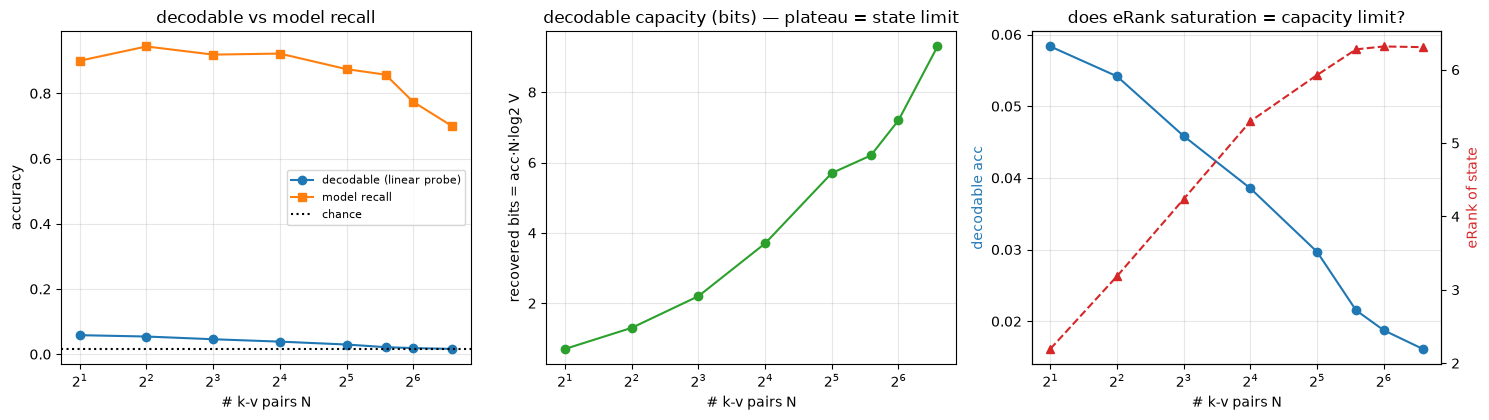

Read: decodable-bits plateau = state's capacity. If eRank saturates BEFORE decodable/recall drop -> eRank is a horizon diagnostic, not the capacity limit (confirms the 200-vs-4k argument).


In [6]:
# 4.1 plots
N = [r["N"] for r in rows]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].plot(N, [r["decodable_acc"] for r in rows], "o-", label="decodable (linear probe)")
ax[0].plot(N, [r["recall_acc"] for r in rows], "s-", label="model recall")
ax[0].axhline(1/VOCAB_V, color="k", ls=":", label="chance")
ax[0].set_xlabel("# k-v pairs N"); ax[0].set_ylabel("accuracy"); ax[0].set_title("decodable vs model recall")
ax[0].set_xscale("log", base=2); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

ax[1].plot(N, [r["decodable_total_bits"] for r in rows], "o-", color="C2")
ax[1].set_xlabel("# k-v pairs N"); ax[1].set_ylabel("recovered bits = acc·N·log2 V")
ax[1].set_title("decodable capacity (bits) — plateau = state limit"); ax[1].set_xscale("log", base=2); ax[1].grid(alpha=.3)

axb = ax[2].twinx()
ax[2].plot(N, [r["decodable_acc"] for r in rows], "o-", color="C0", label="decodable acc")
axb.plot(N, [r["erank"] for r in rows], "^--", color="C3", label="eRank")
ax[2].set_xlabel("# k-v pairs N"); ax[2].set_ylabel("decodable acc", color="C0")
axb.set_ylabel("eRank of state", color="C3"); ax[2].set_title("does eRank saturation = capacity limit?")
ax[2].set_xscale("log", base=2); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "state_capacity_sweep.png"), dpi=120); plt.show()
print("Read: decodable-bits plateau = state's capacity. If eRank saturates BEFORE decodable/recall "
      "drop -> eRank is a horizon diagnostic, not the capacity limit (confirms the 200-vs-4k argument).")

## 5. Interpretation & next
- **Decodable-bits plateau** = an estimate of the state's associative capacity (in bits).
- **eRank saturation point vs the plateau/drop:** earlier ⇒ eRank is a dynamics/horizon signal, not
  capacity; coincident ⇒ eRank is a valid cheap proxy.
- **Model recall** likely ≪ decodable (pretrained, untrained-on-MQAR) — the info is stored but the model
  doesn't read it; a capacity vs mechanism gap.

**TODO next:** control context length separately from N (pad) to fully split horizon vs load; add
slow-head-only decodable; extend to GDN (concat MoM memories); then the deferred **(3) SSC / memory-
routing reuse** test can use these decodable states.